# Prática 3

***Aprendizado Dinâmico***

por **Cibele Russo** (ICMC/USP - São Carlos SP)

**MBA em Ciências de Dados**

Considere as duas bases de dados a seguir

- Dados de fechamento do papel PETR4 de um período de março a julho de 2020 no arquivo PETR4.csv.

- Dados de casos confirmados para COVID-19 no estado de SP.


Nesta prática, aplicaremos os conhecimentos adquiridos na Aula 3 a esses dados, a saber:

- Função de autocorrelação

- Função de autocorrelação parcial

- Repetir a modelagem para os dados de PETR4 visto em aula.

- Para os dados de COVID-19: Um modelo ARIMA sazonal.

**1. Carregue as bibliotecas**

In [1]:
# Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf # para determinar (p,q)


# Ignorar warnings não prejudiciais
import warnings
warnings.filterwarnings("ignore")

**2. Faça a leitura dos dados de PETR4 em df1 e de COVID-19 no estado de SP em df2. Para os dados PETR4 usaremos a variável Close e para os dados de COVID-19 usaremos a variável confirmed. Complete as bases de dados usando reindex e fillna.**

In [2]:
# Leitura dos dados de PETR4 em df1
df1 = pd.read_csv('PETR4.csv', index_col='Date', parse_dates=True)[['Close']]
idx1 = pd.date_range(start=df1.index.min(), end=df1.index.max(), freq='B')
df1 = df1.reindex(idx1).ffill()

# Leitura dos dados de COVID-19 no estado de SP em df2
df2 = pd.read_csv('covidSP.csv', index_col='date', parse_dates=True)[['confirmed']]
idx2 = pd.date_range(start=df2.index.min(), end=df2.index.max(), freq='D')
df2 = df2.reindex(idx2).fillna(0)

Código explicado:

Primeira linha: Leia o arquivo inteiro, mas jogue fora as colunas Open, High, Low, Volume etc. Eu só quero a coluna Close.

Ao usar colchetes duplos [['Close']], você está dizendo ao Pandas: "Trate isso como uma tabela de 2 eixos (Linhas x Colunas), onde por acaso eu só selecionei uma coluna no eixo horizontal".

### 📌 Explicação do Código: Reindexação e Tratamento de Dados Ausentes

Nesta etapa, ajustamos as bases de dados de **PETR4** (`df1`) e **COVID-19** (`df2`) para garantir um alinhamento temporal perfeito entre elas antes da análise.

#### 1. Seleção das Colunas de Interesse
* Ao usar `[['Close']]` e `[['confirmed']]` com **colchetes duplos**, mantemos os dados no formato de **DataFrame** (2 dimensões: linhas × colunas), em vez de convertê-los para uma *Series* (1 dimensão).

#### 2. Criação do Calendário Contínuo (`pd.date_range`)
* **COVID-19 (`idx2`)**: Usamos `freq='D'` (**Daily**) para gerar um intervalo com **todos os dias corridos** entre a menor data (`df2.index.min()`) e a maior data (`df2.index.max()`).
* **PETR4 (`idx1`)**: Usamos `freq='B'` (**Business Days**) para gerar um intervalo contendo apenas os **dias úteis** (dias de funcionamento do mercado financeiro).

#### 3. Reindexação (`reindex`)
* O método `.reindex(novo_indice)` reestrutura a tabela para seguir o calendário contínuo recém-criado.
* Se uma data do calendário não existia originalmente na base de dados, o Pandas cria essa linha preenchendo o valor inicial como `NaN` (*Not a Number* / Dado ausente).

#### 4. Preenchimento de Lacunas (`fillna` / `ffill`)
* **COVID-19 (`.fillna(0)`)**: Preenchemos os dias sem registro com `0`, pois entende-se que não houve novos casos confirmados notificadas naquelas datas ausentes.
* **PETR4 (`.ffill()`)**: Aplicamos o *Forward Fill* (preenchimento para a frente), que repete o último preço de fechamento conhecido do dia útil anterior para cobrir eventuais lacunas da série temporal.

**3. Verifique graficamente se os dados foram lidos de forma correta.**

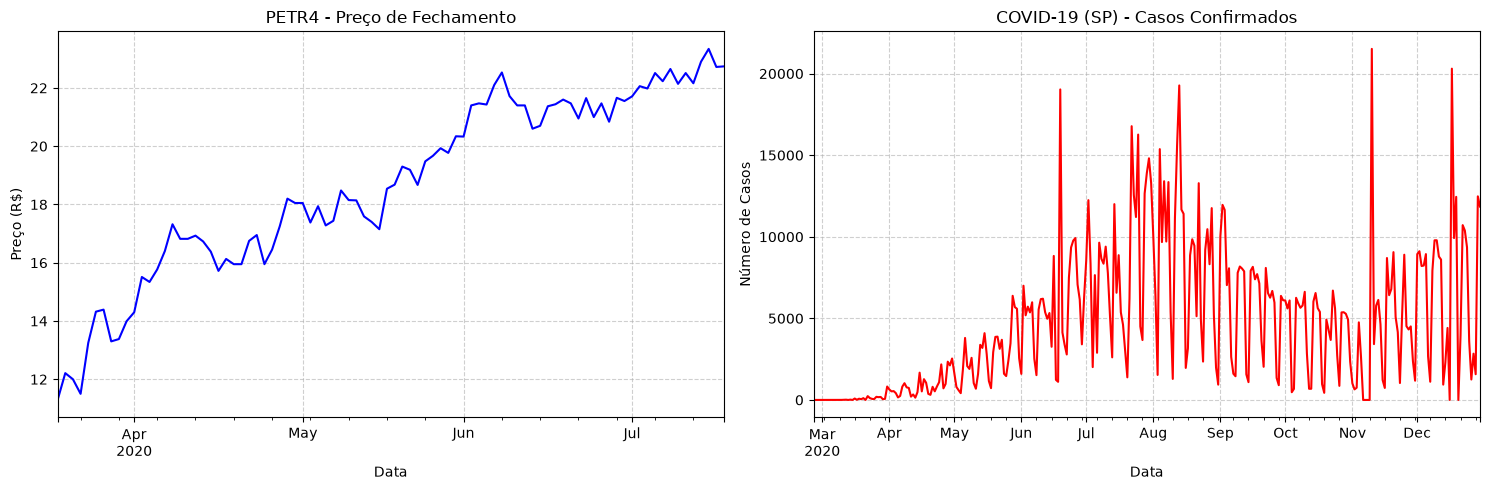

In [3]:
import matplotlib.pyplot as plt

# Cria uma figura com 1 linha e 2 colunas para os gráficos
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Gráfico 1: PETR4
df1['Close'].plot(ax=ax1, color='blue', title='PETR4 - Preço de Fechamento')
ax1.set_ylabel('Preço (R$)')
ax1.set_xlabel('Data')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: COVID-19
df2['confirmed'].plot(ax=ax2, color='red', title='COVID-19 (SP) - Casos Confirmados')
ax2.set_ylabel('Número de Casos')
ax2.set_xlabel('Data')
ax2.grid(True, linestyle='--', alpha=0.6)

# Ajusta o layout para não sobrepor os textos
plt.tight_layout()
plt.show()

**4. Obtenha os gráficos de autocorrelação e autocorrelação parcial para ambas as aplicações. Que características você observa nesses gráficos? Que modelo sugeriria com base nos correlogramas?**

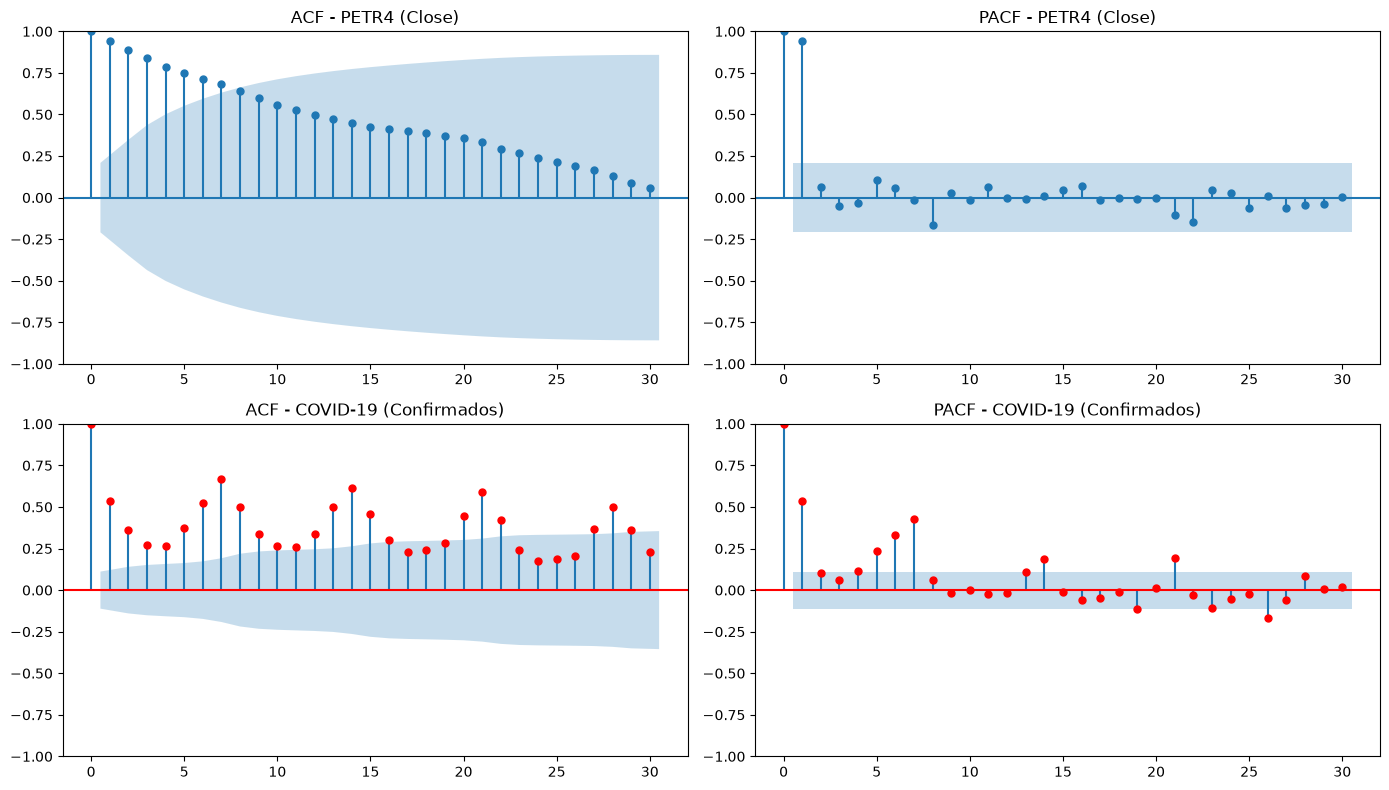

In [4]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Criar uma figura com 2 linhas e 2 colunas para comparar lado a lado
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))

# --- PETR4 ---
plot_acf(df1['Close'], ax=axes[0, 0], lags=30, title='ACF - PETR4 (Close)')
plot_pacf(df1['Close'], ax=axes[0, 1], lags=30, title='PACF - PETR4 (Close)', method='ywm')

# --- COVID-19 ---
plot_acf(df2['confirmed'], ax=axes[1, 0], lags=30, title='ACF - COVID-19 (Confirmados)', color='red')
plot_pacf(df2['confirmed'], ax=axes[1, 1], lags=30, title='PACF - COVID-19 (Confirmados)', color='red', method='ywm')

plt.tight_layout()
plt.show()

**5. Repita os gráficos de autocorrelação e autocorrelação parcial para a primeira diferença de cada aplicação. O que você pode concluir?**

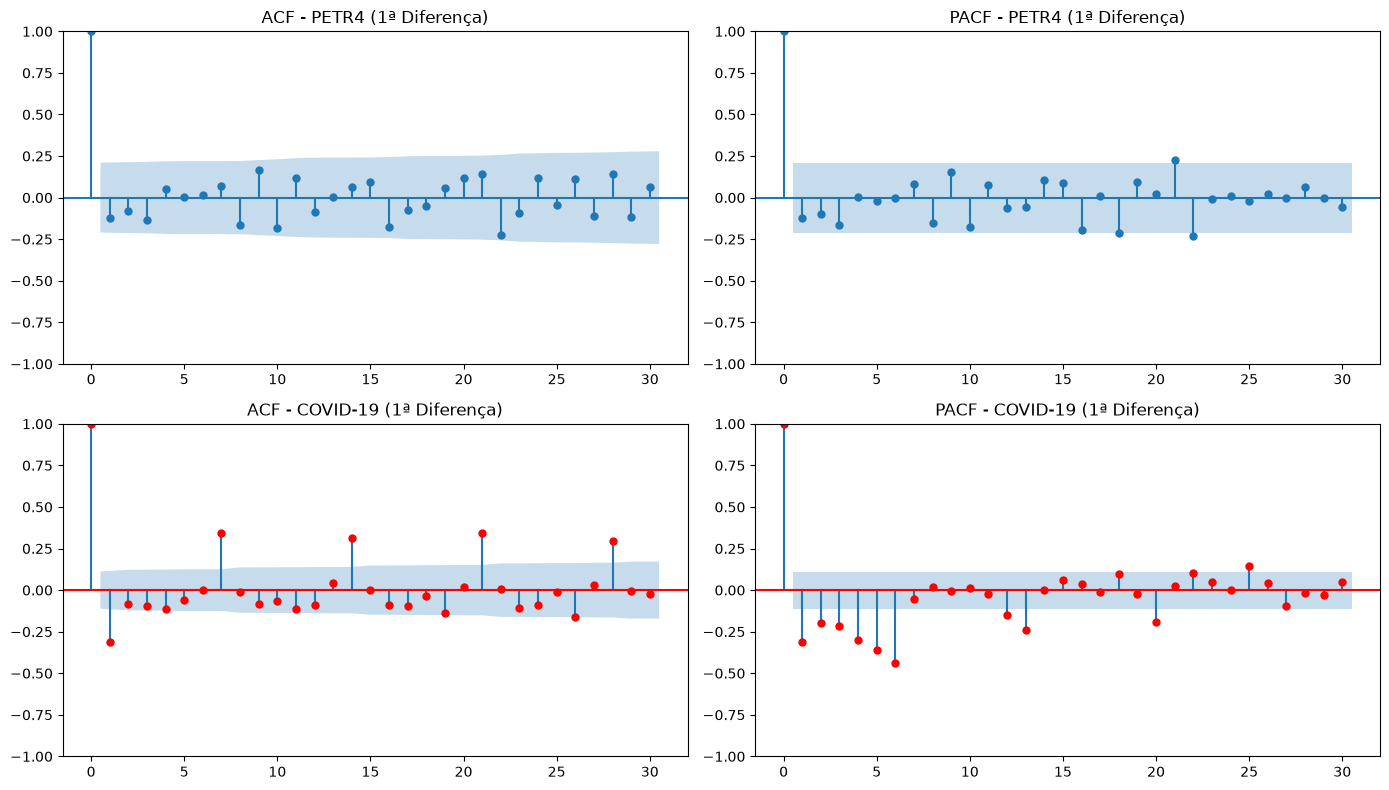

In [5]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Calculando a primeira diferença e removendo o primeiro NaN gerado
df1_diff = df1['Close'].diff().dropna()
df2_diff = df2['confirmed'].diff().dropna()

# 2. Criando a figura (2 linhas x 2 colunas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))

# --- PETR4 (Primeira Diferença) ---
plot_acf(df1_diff, ax=axes[0, 0], lags=30, title='ACF - PETR4 (1ª Diferença)')
plot_pacf(df1_diff, ax=axes[0, 1], lags=30, title='PACF - PETR4 (1ª Diferença)', method='ywm')

# --- COVID-19 (Primeira Diferença) ---
plot_acf(df2_diff, ax=axes[1, 0], lags=30, title='ACF - COVID-19 (1ª Diferença)', color='red')
plot_pacf(df2_diff, ax=axes[1, 1], lags=30, title='PACF - COVID-19 (1ª Diferença)', color='red', method='ywm')

plt.tight_layout()
plt.show()

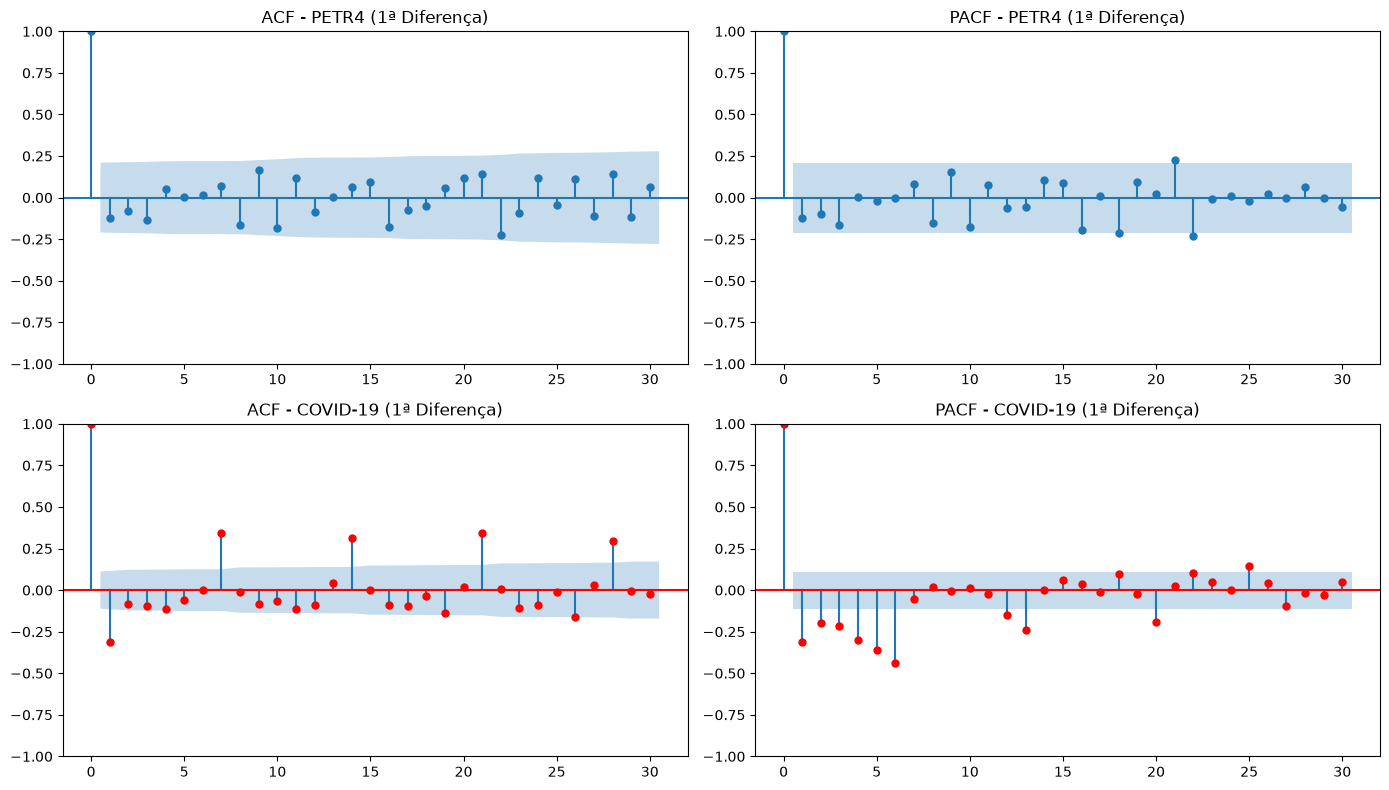

In [6]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Calculando a primeira diferença e removendo o primeiro NaN gerado
df1_diff = df1['Close'].diff().dropna()
df2_diff = df2['confirmed'].diff().dropna()

# 2. Criando a figura (2 linhas x 2 colunas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))

# --- PETR4 (Primeira Diferença) ---
plot_acf(df1_diff, ax=axes[0, 0], lags=30, title='ACF - PETR4 (1ª Diferença)')
plot_pacf(df1_diff, ax=axes[0, 1], lags=30, title='PACF - PETR4 (1ª Diferença)', method='ywm')

# --- COVID-19 (Primeira Diferença) ---
plot_acf(df2_diff, ax=axes[1, 0], lags=30, title='ACF - COVID-19 (1ª Diferença)', color='red')
plot_pacf(df2_diff, ax=axes[1, 1], lags=30, title='PACF - COVID-19 (1ª Diferença)', color='red', method='ywm')

plt.tight_layout()
plt.show()

O que podemos concluir da PETR4?A primeira diferença transformou o preço da PETR4 e### 📊 Conclusões sobre a Primeira Diferença (Questão 5)

#### 1. PETR4 (Primeira Diferença)
* **Comportamento Observado:**
  * A longa ladeira de autocorrelação do gráfico original desapareceu, confirmando que a 1ª diferença tornou a série **estacionária** (estabilizou a média).
  * Tanto no **ACF** quanto no **PACF**, observa-se apenas o **1º lag estourado fora da mancha azul**, com o 2º lag e os seguintes retornando para dentro do intervalo de confiança (sem significância).
* **Conclusão:** 
  * A variação do preço não é um ruído branco puro, pois mantém uma estrutura de ajuste/memória de curto prazo restrita a exatamente 1 dia.
* **Modelo Indicado:** **ARIMA(1, 1, 1)** — ou **ARIMA(0, 1, 1)** —, pois combina 1 diferença ($d=1$) com componentes de ajuste de curto prazo de ordem 1 ($p=1, q=1$) para zerar os resíduos.

In [7]:
import pandas as pd

# PETR4 - Leitura dos dados
df1 = pd.read_csv('PETR4.csv', index_col='Date', parse_dates=True)

idx1 = pd.date_range(start=df1.index.min(), end=df1.index.max(), freq='B')
df1 = df1.reindex(idx1)
df1.fillna(method='ffill', inplace=True)


# COVID-19 no estado de SP
df2 = pd.read_csv('covidSP.csv', index_col='date', parse_dates=True)

idx2 = pd.date_range(start=df2.index.min(), end=df2.index.max(), freq='D')
df2 = df2.reindex(idx2)
df2.fillna(0,inplace=True)


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

import warnings
warnings.filterwarnings("ignore")

stepwise_fit = pm.auto_arima(df1['Close'].values, start_p=0, start_q=0,
                          max_p=2, max_q=2, m=0,
                          seasonal=False,
                          d=None, trace=True,
                          error_action='ignore',   # se uma ordem não convergir, ignorar
                          suppress_warnings=True,  # ignorar avisos
                          stepwise=True)           # executar stepwise

stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=152.390, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=153.013, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=152.598, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=154.944, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=152.746, Time=0.09 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.419 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   88
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -74.195
Date:                Sat, 08 Aug 2026   AIC                            152.390
Time:                        15:46:07   BIC                            157.322
Sample:                             0   HQIC                           154.376
                                 - 88                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1316      0.062      2.124      0.034       0.010       0.253
sigma2         0.3223      0.053      6.046      0.000       0.218       0.427
===================================================================================
Ljung-Box (L1) (Q):                   1.40   Jarque-Bera (JB):                 1.14
Prob(Q):                              0.24   Prob(JB):                         0.57
Heteroskedasticity (H):               0.57   Skew:                             0.25
Prob(H) (two-sided):                  0.14   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
# ARIMA para a PETR4 (Sem sazonalidade: seasonal=False e m=0)
stepwise_fit_petr = pm.auto_arima(df1['Close'], 
                                  start_p=0, start_q=0,
                                  max_p=2, max_q=2, 
                                  m=0,              # <--- Sem ciclo sazonal
                                  seasonal=False,   # <--- Sem SARIMA!
                                  d=None,           # <--- O robô descobre a 1ª diferença sozinho
                                  with_intercept=True, # <--- Garante o teste com intercepto
                                  trace=True,
                                  error_action='ignore',   
                                  suppress_warnings=True,  
                                  stepwise=True)

# Exibe o resumo do melhor modelo
stepwise_fit_petr.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=152.390, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=153.013, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=152.598, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=154.944, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=152.746, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.124 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   88
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -74.195
Date:                Sat, 08 Aug 2026   AIC                            152.390
Time:                        15:46:11   BIC                            157.322
Sample:                    03-18-2020   HQIC                           154.376
                         - 07-17-2020                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1316      0.062      2.124      0.034       0.010       0.253
sigma2         0.3223      0.053      6.046      0.000       0.218       0.427
===================================================================================
Ljung-Box (L1) (Q):                   1.40   Jarque-Bera (JB):                 1.14
Prob(Q):                              0.24   Prob(JB):                         0.57
Heteroskedasticity (H):               0.57   Skew:                             0.25
Prob(H) (two-sided):                  0.14   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [34]:
from statsmodels.tsa.arima.model import ARIMA

# Ajusta direto o modelo ARIMA(1, 1, 1) ou (1, 1, 0) nos dados da PETR4
model = ARIMA(df1['Close'], order=(1, 1, 1))
model_fit = model.fit()

# Exibe o resumo do modelo (exatamente igual ao stepwise_fit.summary())
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                   88
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -76.175
Date:                Sat, 08 Aug 2026   AIC                            158.350
Time:                        14:42:39   BIC                            165.748
Sample:                    03-18-2020   HQIC                           161.329
                         - 07-17-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2925      1.173      0.249      0.803      -2.007       2.592
ma.L1         -0.3723      1.137     -0.327      0.743      -2.601       1.857
sigma2         0.3373      0.051      6.564      0.0

**6. Para os dados de PETR4, refaça a modelagem vista em aula.**

In [10]:
#Instale, se necessário, na versão sugerida
!pip install statsmodels==0.13.5

#Instale, se necessário, na versão sugerida
!pip install pmdarima==2.0.3

In [13]:
# Desafio: Aplicação do SARIMA na série de COVID-19 em SP
stepwise_fit_covid = pm.auto_arima(df2['confirmed'], 
                                   start_p=0, start_q=0,
                                   max_p=2, max_q=2, 
                                   seasonal=True,   # <--- LIGA O SARIMA!
                                   m=7,             # <--- SAZONALIDADE DE 7 DIAS
                                   start_P=0, start_Q=0,
                                   max_P=2, max_Q=2,
                                   d=None, D=None,  # <--- Descobre as diferenças (comuns e sazonais) sozinho
                                   trace=True,
                                   error_action='ignore',   
                                   suppress_warnings=True,  
                                   stepwise=True)

# Exibe o resultado do melhor modelo SARIMA
stepwise_fit_covid.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=6007.140, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=5916.437, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=5845.769, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=6005.169, Time=0.00 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=5891.230, Time=0.02 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=5778.544, Time=0.25 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=5816.796, Time=0.10 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=5761.047, Time=0.33 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=5787.507, Time=0.33 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=5813.794, Time=0.44 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=5924.636, Time=0.25 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=5772.463, Time=0.46 sec
 ARIMA(0,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=5

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  309
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -2874.364
Date:                           Sat, 08 Aug 2026   AIC                           5756.727
Time:                                   15:51:26   BIC                           5771.648
Sample:                               02-26-2020   HQIC                          5762.693
                                    - 12-30-2020                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9021      0.027    -33.593      0.000      -0.955      -0.849
ar.S.L7        0.9673      0.034     28.508      0.000       0.901       1.034
ma.S.L7       -0.7733      0.067    -11.460      0.000      -0.906      -0.641
sigma2      7.315e+06   2.74e+05     26.680      0.000    6.78e+06    7.85e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.52   Jarque-Bera (JB):              2203.69
Prob(Q):                              0.47   Prob(JB):                         0.00
Heteroskedasticity (H):              16.15   Skew:                             1.88
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**7. Desafio: Ainda não vimos o modelo SARIMA, mas já sabemos que a série de COVID-19 tem sazonalidade. Como os dados de COVID-19 apresentam sazonalidade, vamos arriscar no tema da próxima aula? Altere seasonal para True e escolha o melhor modelo entre os SARIMA propostos. Discutiremos com detalhes este modelo na Aula 4.**

In [14]:
stepwise_fit = pm.auto_arima(df2['confirmed'], start_p=0, start_q=0,
                          max_p=3, max_q=3, m=7,
                          seasonal=True,
                          d=None, trace=True,
                          error_action='ignore',   # se uma determinada ordem não convergir, ignorar
                          suppress_warnings=True,  # ignorar avisos
                          stepwise=True)           # executar stepwise

stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=5922.655, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=6007.140, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=5916.437, Time=0.09 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=5845.769, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=6005.169, Time=0.00 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=5891.230, Time=0.02 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=5778.544, Time=0.22 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=5816.796, Time=0.11 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=5761.047, Time=0.32 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=5787.507, Time=0.33 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=5813.794, Time=0.43 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=5924.636, Time=0.25 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=5772.463, Time=0.46 sec
 ARIMA(0,1,2)(2,0,1)[7] intercept   : 

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  309
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -2874.364
Date:                           Sat, 08 Aug 2026   AIC                           5756.727
Time:                                   15:55:40   BIC                           5771.648
Sample:                               02-26-2020   HQIC                          5762.693
                                    - 12-30-2020                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9021      0.027    -33.593      0.000      -0.955      -0.849
ar.S.L7        0.9673      0.034     28.508      0.000       0.901       1.034
ma.S.L7       -0.7733      0.067    -11.460      0.000      -0.906      -0.641
sigma2      7.315e+06   2.74e+05     26.680      0.000    6.78e+06    7.85e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.52   Jarque-Bera (JB):              2203.69
Prob(Q):                              0.47   Prob(JB):                         0.00
Heteroskedasticity (H):              16.15   Skew:                             1.88
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 🚀 Resolução do Desafio: Modelo SARIMA para a COVID-19 em SP

1. **Modelo Selecionado pelo auto_arima:**
   O algoritmo identificou o modelo **SARIMAX$(0, 1, 1) \times (1, 0, 1)_7$** como a melhor opção para a série de casos confirmados, apresentando menor AIC ($5756.72$).

2. **Interpretação dos Parâmetros Sazonais ($m=7$):**
   * **Componente Não-Sazonal $(0,1,1)$:** A aplicação de **1 diferença ($d=1$)** estabilizou a média da série. O parâmetro $MA(1)$ (`ma.L1 = -0.9021`, $p < 0.05$) ajusta os choques imediatos de um dia para o outro.
   * **Componente Sazonal $(1,0,1)_7$:** O termo autorregressivo sazonal (`ar.S.L7 = 0.9673`, $p < 0.05$) confirma matematicamente uma fortíssima dependência dos dados a cada **7 dias** (o ciclo semanal de notificação dos órgãos de saúde).

3. **Diagnóstico dos Resíduos:**
   * **Teste de Ljung-Box (`Prob(Q) = 0.47 > 0.05`):** Passou no teste! Não resta autocorrelação nos resíduos, demonstrando que a estrutura sazonal de 7 dias capturou com precisão o comportamento temporal dos dados.